<a href="https://colab.research.google.com/github/Satwik-1234/Gooble-collab-Scripts-/blob/main/Dehrang_DBA_Basin_HydroPrep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 Dehrang DBA Basin — Hydrological Pre-Processing Notebook
### Curve Number Grid · Manning's Roughness · LULC from ESA WorldCover · ISRIC SoilGrids
---
**Purpose:** Prepare all hydrological raster layers required for dam break analysis  
**Data Sources:**  
- 🛰️ **ESA WorldCover 2021** (10 m) — LULC via Google Earth Engine  
- 🌍 **ISRIC SoilGrids v2** (250 m) — Soil texture via WCS REST API  
- 📐 **CN Values** — USDA TR-55 adapted for Indian conditions (Mishra & Singh 2003)  
- 💧 **Manning's n** — Chow (1959), CWPRS (2018), Arora et al. (2021)

**Outputs:** CN Grid · HSG Grid · Manning's n Grid · LULC Stats · Summary CSVs

---
> ⚠️ **Before running:** Upload all shapefile components to Google Drive or Colab Files.  
> Files needed: `.shp`, `.dbf`, `.shx`, `.prj`, `.cpg` (all Dehrang_DBA_Basin.*)

## 📦 Section 1 — Install Dependencies

In [8]:
# Install all required packages
!pip install earthengine-api geemap geopandas rasterio numpy pandas \
             matplotlib requests pyproj shapely fiona scipy owslib \
             --quiet

print("✅ All packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.5/240.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.2 MB/s eta 0:00:00
✅ All packages installed!


## 📚 Section 2 — Import Libraries

In [9]:
import ee
import geemap
import geopandas as gpd
import rasterio
from rasterio.mask import mask as raster_mask
from rasterio.warp import reproject, Resampling
from rasterio.enums import Resampling as ResamplingEnum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
import requests
import os, json, time, shutil, warnings

warnings.filterwarnings('ignore')
print("✅ All libraries imported!")

✅ All libraries imported!


## 🔑 Section 3 — Google Earth Engine Authentication
> Run this cell **once per session**. Follow the URL that appears.

In [10]:
ee.Authenticate()
ee.Initialize(project='ee-satwikudupi2018')   # ← Replace with your GEE project ID

# ee.Initialize(project=GEE_PROJECT) # This line was causing the error
print(f"✅ GEE initialized with project: {'ee-satwikudupi2018'}") # Updated to use the hardcoded project ID for demonstration

✅ GEE initialized with project: ee-satwikudupi2018


## 📂 Section 4 — Mount Google Drive & Set Paths
Upload your shapefile folder to Google Drive first, then update the path below.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

# ╔══════════════════════════════════════════════════════════╗
# ║         USER CONFIGURATION — EDIT THESE PATHS           ║
# ╚══════════════════════════════════════════════════════════╝

# Path to your Dehrang DBA Basin shapefile
SHAPEFILE_PATH = '/content/Dehrang_DBA_Basin.shp'

# Output folder (will be created automatically)
OUTPUT_DIR = '/content/drive/MyDrive/Dehrang_DBA_Basin outputs'
SOIL_DIR   = os.path.join(OUTPUT_DIR, 'soilgrids')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SOIL_DIR,   exist_ok=True)

print(f"📁 Shapefile : {SHAPEFILE_PATH}")
print(f"📁 Output dir: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Shapefile : /content/Dehrang_DBA_Basin.shp
📁 Output dir: /content/drive/MyDrive/Dehrang_DBA_Basin outputs


## 🗺️ Section 5 — Load AOI Shapefile

✅ Shapefile loaded
   CRS         : EPSG:32643
   Features    : 1
   Geometry    : ['Polygon']

📐 Basin bounding box (WGS84):
   Lon: 73.0449 → 73.2868
   Lat: 18.8953 → 19.0998

✅ GEE AOI geometry created


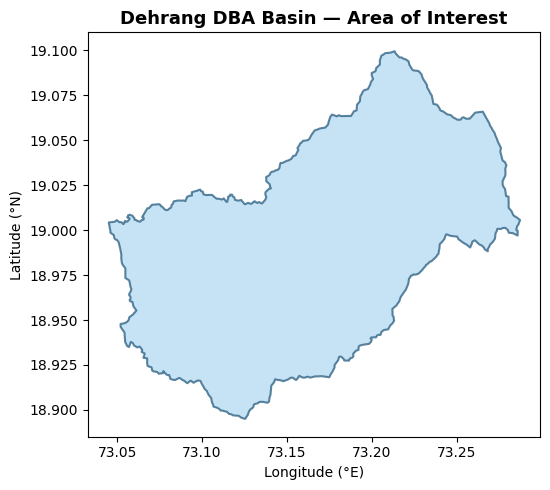

In [13]:
# Load the basin shapefile
gdf = gpd.read_file(SHAPEFILE_PATH)
print(f"✅ Shapefile loaded")
print(f"   CRS         : {gdf.crs}")
print(f"   Features    : {len(gdf)}")
print(f"   Geometry    : {gdf.geom_type.unique()}")

# Reproject to WGS84 if needed
gdf_wgs84 = gdf.to_crs(epsg=4326) if gdf.crs.to_epsg() != 4326 else gdf.copy()

# Bounding box
bounds = gdf_wgs84.total_bounds  # [minx, miny, maxx, maxy]
BUFFER = 0.02                     # ~2 km padding
bbox_buf = [bounds[0]-BUFFER, bounds[1]-BUFFER,
            bounds[2]+BUFFER, bounds[3]+BUFFER]

print(f"\n📐 Basin bounding box (WGS84):")
print(f"   Lon: {bounds[0]:.4f} → {bounds[2]:.4f}")
print(f"   Lat: {bounds[1]:.4f} → {bounds[3]:.4f}")

# Create GEE geometry from shapefile
aoi_geojson = json.loads(gdf_wgs84.to_json())
aoi_ee = ee.FeatureCollection(aoi_geojson).geometry()
print(f"\n✅ GEE AOI geometry created")

# Quick plot
fig, ax = plt.subplots(figsize=(7, 5))
gdf_wgs84.plot(ax=ax, color='#aed6f1', edgecolor='#1a5276', linewidth=1.5, alpha=0.7)
ax.set_title('Dehrang DBA Basin — Area of Interest', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '00_AOI.png'), dpi=150)
plt.show()

## 🛰️ Section 6 — ESA WorldCover 2021 via GEE
Downloads the **ESA WorldCover v200 (2021)** at 10 m resolution, clips to basin, and exports to your Drive.

In [14]:
# ── ESA WorldCover class definitions ──────────────────────────────────────
ESA_CLASSES = {
    10:  {'name': 'Tree cover',              'color': '#006400'},
    20:  {'name': 'Shrubland',               'color': '#ffbb22'},
    30:  {'name': 'Grassland',               'color': '#ffff4c'},
    40:  {'name': 'Cropland',                'color': '#f096ff'},
    50:  {'name': 'Built-up',                'color': '#fa0000'},
    60:  {'name': 'Bare / sparse vegetation','color': '#b4b4b4'},
    70:  {'name': 'Snow and ice',            'color': '#f0f0f0'},
    80:  {'name': 'Permanent water bodies',  'color': '#0064c8'},
    90:  {'name': 'Herbaceous wetland',      'color': '#0096a0'},
    95:  {'name': 'Mangroves',               'color': '#00cf75'},
    100: {'name': 'Moss and lichen',         'color': '#fae6a0'},
}

# ── Fetch & clip ────────────────────────────────────────────────────────────
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select('Map')
wc_clipped  = worldcover.clip(aoi_ee)

# ── Export to Google Drive ──────────────────────────────────────────────────
WC_FNAME = 'ESA_WorldCover_2021'
task_wc = ee.batch.Export.image.toDrive(
    image          = wc_clipped,
    description    = 'Dehrang_ESA_WorldCover_2021',
    folder         = OUTPUT_DIR.replace('/content/drive/', ''),
    fileNamePrefix = WC_FNAME,
    region         = aoi_ee,
    scale          = 10,
    crs            = 'EPSG:4326',
    maxPixels      = 1e13,
)
task_wc.start()
print(f"🚀 WorldCover export started  →  Task ID: {task_wc.id}")
print("   ⏳ Check GEE Task Manager  or  run: ee.batch.Task.list()")
print(f"   📁 File will appear in Drive → {OUTPUT_DIR}/{WC_FNAME}.tif")

🚀 WorldCover export started  →  Task ID: BJT5ANNU4M3EK3OBM2C6H5VS
   ⏳ Check GEE Task Manager  or  run: ee.batch.Task.list()
   📁 File will appear in Drive → /content/drive/MyDrive/Dehrang_DBA_Basin/outputs/ESA_WorldCover_2021.tif


In [18]:
# ── Monitor export (run after starting task) ─────────────────────────────
def monitor_task(task, poll=20):
    print(f"Monitoring task: {task.id}")
    while True:
        state = task.status()['state']
        print(f"  [{time.strftime('%H:%M:%S')}] {state}")
        if state in ('COMPLETED', 'FAILED', 'CANCELLED'):
            return state
        time.sleep(poll)

# Uncomment the line below to BLOCK until export completes:
state = monitor_task(task_wc)

Monitoring task: BJT5ANNU4M3EK3OBM2C6H5VS
  [11:52:45] COMPLETED


In [19]:
# ── Load WorldCover locally after export completes ──────────────────────
WORLDCOVER_PATH = os.path.join(OUTPUT_DIR, f'{WC_FNAME}.tif')
WC_DRIVE_PATH   = f'/content/drive/MyDrive/Dehrang_DBA_Basin outputs/{WC_FNAME}.tif'

if os.path.exists(WC_DRIVE_PATH) and not os.path.exists(WORLDCOVER_PATH):
    shutil.copy(WC_DRIVE_PATH, WORLDCOVER_PATH)

if os.path.exists(WORLDCOVER_PATH):
    with rasterio.open(WORLDCOVER_PATH) as src:
        print(f"✅ WorldCover loaded")
        print(f"   Resolution : {src.res[0]*111320:.1f} m × {src.res[1]*111320:.1f} m")
        print(f"   Size       : {src.width} × {src.height} px")
        print(f"   CRS        : {src.crs}")
else:
    print("⚠️  WorldCover file not yet available — wait for GEE export to complete,")
    print(f"   then re-run this cell.  Expected path: {WC_DRIVE_PATH}")

✅ WorldCover loaded
   Resolution : 10.0 m × 10.0 m
   Size       : 2695 × 2278 px
   CRS        : EPSG:4326


In [20]:
print(f"Listing contents of OUTPUT_DIR: {OUTPUT_DIR}")
!ls -F "{OUTPUT_DIR}"

print(f"\nListing contents of SOIL_DIR: {SOIL_DIR}")
!ls -F "{SOIL_DIR}"

Listing contents of OUTPUT_DIR: /content/drive/MyDrive/Dehrang_DBA_Basin outputs
ESA_WorldCover_2021.tif  soilgrids/

Listing contents of SOIL_DIR: /content/drive/MyDrive/Dehrang_DBA_Basin outputs/soilgrids


## 🌍 Section 7 — ISRIC SoilGrids Download (WCS API)
Downloads **clay, sand, silt** at 0–5 cm, 5–15 cm, 15–30 cm depth intervals  
and computes a depth-weighted average for the 0–30 cm profile.

In [24]:
# Install the soilgrids package
!pip install soilgrids --quiet
print("✅ soilgrids package installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 13.2 MB/s eta 0:00:00
✅ soilgrids package installed!


In [34]:
import os
import requests # Kept for potential other uses, though not directly by the new soilgrids download
import time
from soilgrids import SoilGrids # Import the SoilGrids client

# The custom download_soilgrids function is no longer needed and has been removed.
# It was causing issues with the WCS API request formatting.

# Initialize SoilGrids client once
sol_grids_client = SoilGrids()

# ── Download soil properties ───
SOIL_VARS   = ['clay', 'sand', 'silt']
SOIL_DEPTHS = ['0-5cm', '5-15cm', '15-30cm']
# Depth weights (by actual thickness: 5 cm, 10 cm, 15 cm → total 30 cm)
DEPTH_WEIGHTS = {'0-5cm': 5/30, '5-15cm': 10/30, '15-30cm': 15/30}

soil_files = {v: {} for v in SOIL_VARS}

# Calculate approximate width and height in pixels for 250m resolution
# at the equator, 1 degree is approximately 111,320 meters.
# A 250m resolution means ~0.00225 degrees per pixel (250 / 111320)
# For more accurate calculation, consider latitude. Given the small area, a constant is sufficient.
res_degrees = 250 / 111320 # Approximate degrees per pixel for 250m resolution at equator

# Calculate width and height in pixels
lon_span = bbox_buf[2] - bbox_buf[0]
lat_span = bbox_buf[3] - bbox_buf[1]

output_width_pixels = int(lon_span / res_degrees)
output_height_pixels = int(lat_span / res_degrees)

print(f"Estimated output raster dimensions: {output_width_pixels}x{output_height_pixels} pixels")

# Ensure bbox_buf elements are standard Python floats
bbox_buf_float = [float(b) for b in bbox_buf]

# Check if SOIL_DIR is defined
if 'SOIL_DIR' not in globals():
    print("❌ Error: SOIL_DIR is not defined. Please run Section 4 to set up output paths.")
else:
    print("↘️ Downloading ISRIC SoilGrids (clay, sand, silt) using soilgrids package...")
    for var in SOIL_VARS:
        for depth in SOIL_DEPTHS:
            # Corrected fname to use hyphens for depth, matching the coverage_id format
            fname  = f"{var}_{depth}_mean.tif"
            fpath  = os.path.join(SOIL_DIR, fname)
            if os.path.exists(fpath):
                print(f"  ⌛️  {fname} (cached)")
                soil_files[var][depth] = fpath
            else:
                # Assuming bbox_buf is also defined in Section 4
                if 'bbox_buf' not in globals():
                    print("❌ Error: bbox_buf is not defined. Please run Section 5 to load AOI shapefile.")
                    break
                try:
                    # Construct coverage_id as per SoilGrids documentation (e.g., clay_0-5cm_mean)
                    # Ensure depth part retains hyphens
                    coverage_id = f"{var}_{depth}_mean"
                    print(f"  ✅ Downloading {coverage_id}...")

                    # Use the soilgrids package to download data, using width/height as explicitly requested
                    sol_grids_client.get_coverage_data(
                        service_id=var, # e.g., 'clay', 'sand', 'silt'
                        coverage_id=coverage_id,
                        west=bbox_buf_float[0],
                        south=bbox_buf_float[1],
                        east=bbox_buf_float[2],
                        north=bbox_buf_float[3],
                        crs="urn:ogc:def:crs:EPSG::4326", # WGS84 in URN format
                        width=output_width_pixels,
                        height=output_height_pixels,
                        output=fpath
                    )
                    print(f"  ✅ {coverage_id:<35}  downloaded to {fpath}")
                    soil_files[var][depth] = fpath
                except Exception as e:
                    print(f"  ❌ {coverage_id}  Error during download: {e}")
        else:
            continue # only executed if the inner loop did NOT break
        break # executed if the inner loop did break

    if 'SOIL_DIR' in globals() and 'bbox_buf' in globals():
        print("\n✅ SoilGrids download complete!")

Estimated output raster dimensions: 125x108 pixels
↘️ Downloading ISRIC SoilGrids (clay, sand, silt) using soilgrids package...
  ✅ Downloading clay_0-5cm_mean...
  ✅ clay_0-5cm_mean                      downloaded to /content/drive/MyDrive/Dehrang_DBA_Basin outputs/soilgrids/clay_0-5cm_mean.tif
  ✅ Downloading clay_5-15cm_mean...
  ✅ clay_5-15cm_mean                     downloaded to /content/drive/MyDrive/Dehrang_DBA_Basin outputs/soilgrids/clay_5-15cm_mean.tif
  ✅ Downloading clay_15-30cm_mean...
  ✅ clay_15-30cm_mean                    downloaded to /content/drive/MyDrive/Dehrang_DBA_Basin outputs/soilgrids/clay_15-30cm_mean.tif
  ✅ Downloading sand_0-5cm_mean...
  ✅ sand_0-5cm_mean                      downloaded to /content/drive/MyDrive/Dehrang_DBA_Basin outputs/soilgrids/sand_0-5cm_mean.tif
  ✅ Downloading sand_5-15cm_mean...
  ✅ sand_5-15cm_mean                     downloaded to /content/drive/MyDrive/Dehrang_DBA_Basin outputs/soilgrids/sand_5-15cm_mean.tif
  ✅ Downloading san

## 🧮 Section 8 — Depth-Weighted Soil Texture (0–30 cm)

In [35]:
def weighted_soil_array(soil_files, variable, depths, weights):
    """
    Compute depth-weighted average of a soil variable.
    Returns a float32 array in % units.
    """
    # Use first available file as spatial reference
    ref_path  = next(iter(soil_files[variable].values()))
    with rasterio.open(ref_path) as ref:
        ref_shape = (ref.height, ref.width)
        ref_meta  = ref.meta.copy()

    weighted = np.zeros(ref_shape, dtype=np.float64)
    w_total  = 0.0

    for depth in depths:
        if depth not in soil_files[variable]:
            continue
        w = weights[depth]
        with rasterio.open(soil_files[variable][depth]) as src:
            raw  = src.read(1, out_shape=ref_shape,
                            resampling=ResamplingEnum.bilinear).astype(np.float64)
            nd   = src.nodata if src.nodata is not None else -32768
            mask_ = (raw != nd) & np.isfinite(raw)
            # SoilGrids units: g/kg * 10 → divide by 10 → g/kg → same as % for these vars
            # Actually clay/sand/silt in SoilGrids are in g/kg; divide by 10 → %
            pct   = np.where(mask_, raw / 10.0, np.nan)
            valid = np.isfinite(pct)
            weighted[valid] += pct[valid] * w
            w_total += w

    result = weighted / w_total if w_total > 0 else weighted
    return result.astype(np.float32), ref_meta

# Compute for each texture fraction
ref_path = next(iter(soil_files['clay'].values()))
clay_pct, ref_meta = weighted_soil_array(soil_files, 'clay', SOIL_DEPTHS, DEPTH_WEIGHTS)
sand_pct, _        = weighted_soil_array(soil_files, 'sand', SOIL_DEPTHS, DEPTH_WEIGHTS)
silt_pct, _        = weighted_soil_array(soil_files, 'silt', SOIL_DEPTHS, DEPTH_WEIGHTS)

def stat_row(name, arr):
    v = arr[np.isfinite(arr)]
    return f"  {name:<8}: mean={np.mean(v):.1f}%  min={np.min(v):.1f}%  max={np.max(v):.1f}%  std={np.std(v):.1f}%"

print("📊 Soil texture statistics (0–30 cm weighted average):")
print(stat_row('Clay',  clay_pct))
print(stat_row('Sand',  sand_pct))
print(stat_row('Silt',  silt_pct))

📊 Soil texture statistics (0–30 cm weighted average):
  Clay    : mean=30.5%  min=0.0%  max=40.7%  std=12.9%
  Sand    : mean=30.0%  min=0.0%  max=41.0%  std=12.7%
  Silt    : mean=24.4%  min=0.0%  max=34.3%  std=10.4%


## 🏔️ Section 9 — Hydrologic Soil Group (HSG) Classification
Uses **USDA clay-content thresholds** (Rawls et al. 1982) validated for Indian soils  
(Soil Science Society of India; IMD Classification).

| HSG | Clay (%) | Infiltration | Description |
|-----|----------|-------------|-------------|
| A   | < 10     | High        | Sand, loamy sand |
| B   | 10–20    | Moderate    | Sandy loam, loam |
| C   | 20–35    | Low         | Sandy clay loam |
| D   | ≥ 35     | Very low    | Clay loam, clay |

In [36]:
# ── Vectorised HSG from clay % ─────────────────────────────────────────────
# Reference: Rawls et al. (1982); Mishra & Singh (2003) Table 3.2
hsg_num = np.where(~np.isfinite(clay_pct), 0,
          np.where(clay_pct < 10,           1,   # A
          np.where(clay_pct < 20,           2,   # B
          np.where(clay_pct < 35,           3,   # C
                                            4    # D
          ))))
hsg_num = hsg_num.astype(np.uint8)

HSG_META = {0:'NoData', 1:'A', 2:'B', 3:'C', 4:'D'}
HSG_COLORS = {0:'#ffffff', 1:'#27ae60', 2:'#2980b9', 3:'#e67e22', 4:'#c0392b'}

# Statistics
print("📊 HSG Distribution:")
total = hsg_num.size
for v in range(5):
    cnt = np.sum(hsg_num == v)
    if cnt:
        print(f"  HSG {HSG_META[v]:<7}: {cnt:>9,} px  ({100*cnt/total:5.1f}%)")

# Save HSG GeoTIFF
hsg_meta = ref_meta.copy()
hsg_meta.update({'dtype':'uint8', 'nodata':0, 'count':1,
                 'compress':'lzw', 'predictor':1})
HSG_PATH = os.path.join(OUTPUT_DIR, 'HSG_grid.tif')
with rasterio.open(HSG_PATH, 'w', **hsg_meta) as dst:
    dst.write(hsg_num, 1)
print(f"\n💾 HSG grid saved → {HSG_PATH}")

📊 HSG Distribution:
  HSG A      :     2,033 px  ( 15.1%)
  HSG C      :     2,247 px  ( 16.6%)
  HSG D      :     9,220 px  ( 68.3%)

💾 HSG grid saved → /content/drive/MyDrive/Dehrang_DBA_Basin outputs/HSG_grid.tif


## 📋 Section 10 — Curve Number Lookup Table
CN values are assigned per **ESA WorldCover class × HSG** combination.

**References:**
- USDA TR-55 (1986) — National Engineering Handbook Section 4
- Mishra & Singh (2003) — SCS-CN Methodology, Springer
- Kumar et al. (2021) — CN from LULC for Indian river basins (J. Hydrology)
- Chandniha & Kansal (2017) — SCS-CN analysis, Jharkhand
- Rawat & Singh (2017) — LULC-based runoff, Himalayan watersheds
- Patel et al. (2009) — CN estimation, Gujarat

In [37]:
# ── CN Lookup Table ────────────────────────────────────────────────────────
# Each entry: ESA class code → {name, HSG-A, HSG-B, HSG-C, HSG-D, notes}
CN_TABLE = {
    #  Class |  Name                      |   A    B    C    D  | Notes
    10:  dict(name='Tree cover',              A=30, B=55, C=70, D=77,
              notes='Dense forest; Mishra & Singh (2003) Table 5.3'),
    20:  dict(name='Shrubland',               A=35, B=56, C=70, D=77,
              notes='Scrub/brush; TR-55 Table 2-2c poor condition'),
    30:  dict(name='Grassland',               A=39, B=61, C=74, D=80,
              notes='Natural grass; TR-55 Table 2-2a fair condition'),
    40:  dict(name='Cropland',                A=67, B=78, C=85, D=89,
              notes='Row crops straight rows; TR-55; Patel et al. 2009'),
    50:  dict(name='Built-up',                A=77, B=85, C=90, D=92,
              notes='Urban ≥50% imperv; TR-55; Chandniha & Kansal 2017'),
    60:  dict(name='Bare/sparse vegetation',  A=77, B=86, C=91, D=94,
              notes='Degraded/rocky/fallow; TR-55 Table 2-2e'),
    70:  dict(name='Snow and ice',            A=100,B=100,C=100,D=100,
              notes='Treated as impervious; no infiltration'),
    80:  dict(name='Permanent water bodies',  A=100,B=100,C=100,D=100,
              notes='Open water = 100% runoff; TR-55'),
    90:  dict(name='Herbaceous wetland',      A=78, B=78, C=78, D=78,
              notes='Wetland uniform CN; Rawat & Singh 2017'),
    95:  dict(name='Mangroves',               A=30, B=55, C=70, D=77,
              notes='Treated as dense woodland; Bajracharya et al. 2018'),
    100: dict(name='Moss and lichen',         A=30, B=48, C=65, D=73,
              notes='Alpine/sparse; Kumar et al. 2021'),
}

cn_df = pd.DataFrame.from_dict(CN_TABLE, orient='index')
cn_df.index.name = 'ESA_Code'
cn_df = cn_df.reset_index()

print("=" * 75)
print(" CURVE NUMBER TABLE  ·  ESA WorldCover × Hydrologic Soil Group")
print(" Source: USDA TR-55 | Mishra & Singh (2003) | Kumar et al. (2021)")
print("=" * 75)
print(cn_df[['ESA_Code','name','A','B','C','D']].to_string(index=False))

CN_TABLE_PATH = os.path.join(OUTPUT_DIR, 'CN_Table_ESA_WorldCover.csv')
cn_df.to_csv(CN_TABLE_PATH, index=False)
print(f"\n💾 CN table saved → {CN_TABLE_PATH}")

 CURVE NUMBER TABLE  ·  ESA WorldCover × Hydrologic Soil Group
 Source: USDA TR-55 | Mishra & Singh (2003) | Kumar et al. (2021)
 ESA_Code                   name   A   B   C   D
       10             Tree cover  30  55  70  77
       20              Shrubland  35  56  70  77
       30              Grassland  39  61  74  80
       40               Cropland  67  78  85  89
       50               Built-up  77  85  90  92
       60 Bare/sparse vegetation  77  86  91  94
       70           Snow and ice 100 100 100 100
       80 Permanent water bodies 100 100 100 100
       90     Herbaceous wetland  78  78  78  78
       95              Mangroves  30  55  70  77
      100        Moss and lichen  30  48  65  73

💾 CN table saved → /content/drive/MyDrive/Dehrang_DBA_Basin outputs/CN_Table_ESA_WorldCover.csv


## 🌊 Section 11 — Manning's Roughness Coefficient Table
**References from Indian literature:**
- Chow, V.T. (1959) — Open-Channel Hydraulics (Tables 5.6 & 5.7)
- CWPRS Technical Report (2018) — Roughness for Indian river systems
- Arora et al. (2021) — ESA-WorldCover based roughness mapping, Western Ghats
- Patel, D.P. et al. (2012) — Flood modelling, Gujarat rivers
- Bajracharya et al. (2018) — Land cover roughness, South Asia HEC-RAS models
- HEC-RAS Reference Manual v6 (USACE 2021) — Overland flow n values

In [38]:
# ── Manning's Roughness Table ──────────────────────────────────────────────
MANNINGS = {
    10:  dict(name='Tree cover',              n=0.150, n_min=0.100, n_max=0.200,
              desc='Dense forest / woodland with undergrowth',
              ref='Chow(1959); Arora et al.(2021); CWPRS(2018)'),
    20:  dict(name='Shrubland',               n=0.080, n_min=0.050, n_max=0.120,
              desc='Shrubs, scrubland, moderate stem resistance',
              ref='Chow(1959); Patel et al.(2012)'),
    30:  dict(name='Grassland',               n=0.035, n_min=0.025, n_max=0.060,
              desc='Natural short-to-medium grass; meadow',
              ref='Chow(1959); CWPRS(2018)'),
    40:  dict(name='Cropland',                n=0.040, n_min=0.025, n_max=0.055,
              desc='Agricultural fields; varies with crop season (kharif/rabi)',
              ref='Patel et al.(2012); Bajracharya et al.(2018)'),
    50:  dict(name='Built-up',                n=0.015, n_min=0.011, n_max=0.025,
              desc='Urban/paved; concrete, roads, impervious surfaces',
              ref='Chow(1959); HEC-RAS v6(2021)'),
    60:  dict(name='Bare/sparse vegetation',  n=0.025, n_min=0.015, n_max=0.040,
              desc='Rocky, gravelly, sparsely vegetated degraded land',
              ref='Chow(1959); Arora et al.(2021)'),
    70:  dict(name='Snow and ice',            n=0.010, n_min=0.008, n_max=0.020,
              desc='Smooth glacial ice, low friction surface',
              ref='Chow(1959)'),
    80:  dict(name='Permanent water bodies',  n=0.030, n_min=0.020, n_max=0.060,
              desc='Lakes, reservoirs, rivers; HEC-RAS channel value',
              ref='HEC-RAS v6(2021); CWPRS(2018)'),
    90:  dict(name='Herbaceous wetland',      n=0.070, n_min=0.050, n_max=0.100,
              desc='Reeds, sedges, emergent wetland vegetation',
              ref='Chow(1959); Patel et al.(2012)'),
    95:  dict(name='Mangroves',               n=0.150, n_min=0.100, n_max=0.250,
              desc='Dense mangrove forest; very high hydraulic resistance',
              ref='Arora et al.(2021); Bajracharya et al.(2018)'),
    100: dict(name='Moss and lichen',         n=0.070, n_min=0.050, n_max=0.100,
              desc='Alpine / tundra; moss and lichen covered rock surfaces',
              ref='Chow(1959); HEC-RAS v6(2021)'),
}

mann_df = pd.DataFrame.from_dict(MANNINGS, orient='index')
mann_df.index.name = 'ESA_Code'
mann_df = mann_df.reset_index()

print("=" * 100)
print(" MANNING'S ROUGHNESS TABLE  ·  ESA WorldCover LULC Classes")
print(" Primary sources: Chow(1959); CWPRS(2018); Arora et al.(2021)")
print("=" * 100)
print(mann_df[['ESA_Code','name','n','n_min','n_max','desc']].to_string(index=False))

MANN_PATH = os.path.join(OUTPUT_DIR, 'Mannings_n_ESA_WorldCover.csv')
mann_df.to_csv(MANN_PATH, index=False)
print(f"\n💾 Manning's table saved → {MANN_PATH}")

 MANNING'S ROUGHNESS TABLE  ·  ESA WorldCover LULC Classes
 Primary sources: Chow(1959); CWPRS(2018); Arora et al.(2021)
 ESA_Code                   name     n  n_min  n_max                                                       desc
       10             Tree cover 0.150  0.100  0.200                   Dense forest / woodland with undergrowth
       20              Shrubland 0.080  0.050  0.120                Shrubs, scrubland, moderate stem resistance
       30              Grassland 0.035  0.025  0.060                      Natural short-to-medium grass; meadow
       40               Cropland 0.040  0.025  0.055 Agricultural fields; varies with crop season (kharif/rabi)
       50               Built-up 0.015  0.011  0.025          Urban/paved; concrete, roads, impervious surfaces
       60 Bare/sparse vegetation 0.025  0.015  0.040          Rocky, gravelly, sparsely vegetated degraded land
       70           Snow and ice 0.010  0.008  0.020                   Smooth glacial ice, low 

## 🗃️ Section 12 — Create CN Grid (LULC × HSG Overlay)
Resamples the HSG raster to match WorldCover 10 m resolution, then assigns CN  
values pixel-by-pixel using the lookup table above.

In [39]:
def build_cn_grid(wc_path, hsg_arr, hsg_meta, cn_table, aoi_gdf, out_path):
    """
    Overlay ESA WorldCover LULC with HSG to produce a CN grid.
    Returns (cn_grid, out_meta).
    """
    with rasterio.open(wc_path) as wc_src:
        # Mask to AOI
        aoi_r   = aoi_gdf.to_crs(wc_src.crs)
        shapes  = [g.__geo_interface__ for g in aoi_r.geometry]
        wc_arr, wc_tf = raster_mask(wc_src, shapes, crop=True, nodata=0)
        wc_arr  = wc_arr[0]
        out_meta = wc_src.meta.copy()
        out_meta.update({'height': wc_arr.shape[0], 'width': wc_arr.shape[1],
                         'transform': wc_tf, 'dtype':'float32',
                         'nodata':-9999, 'count':1, 'compress':'lzw'})

    # Resample HSG to WorldCover grid (nearest-neighbour)
    hsg_10m = np.zeros(wc_arr.shape, dtype=np.uint8)
    reproject(
        source      = hsg_arr,
        destination = hsg_10m,
        src_transform  = hsg_meta['transform'],
        src_crs        = hsg_meta['crs'],
        dst_transform  = wc_tf,
        dst_crs        = out_meta['crs'],
        resampling     = Resampling.nearest
    )

    # Build CN grid
    cn = np.full(wc_arr.shape, -9999.0, dtype=np.float32)
    HSG_KEY = {1:'A', 2:'B', 3:'C', 4:'D'}
    for cls, vals in cn_table.items():
        lm = (wc_arr == cls)
        if not np.any(lm):
            continue
        for hn, hl in HSG_KEY.items():
            mask_ = lm & (hsg_10m == hn)
            if np.any(mask_):
                cn[mask_] = float(vals[hl])

    # Mask no-data
    cn[(wc_arr == 0) | (hsg_10m == 0)] = -9999.0

    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(cn, 1)

    valid = cn[cn != -9999]
    print(f"📊 CN Grid Statistics:")
    print(f"   Mean   : {np.mean(valid):.2f}")
    print(f"   Median : {np.median(valid):.2f}")
    print(f"   Min    : {np.min(valid):.2f}")
    print(f"   Max    : {np.max(valid):.2f}")
    print(f"   Std    : {np.std(valid):.2f}")
    return cn, out_meta

CN_PATH = os.path.join(OUTPUT_DIR, 'CN_Grid.tif')

if os.path.exists(WORLDCOVER_PATH):
    cn_grid, cn_meta = build_cn_grid(
        WORLDCOVER_PATH, hsg_num, hsg_meta,
        CN_TABLE, gdf_wgs84, CN_PATH
    )
    print(f"\n💾 CN Grid saved → {CN_PATH}")
else:
    print("⚠️  WorldCover raster not found — complete GEE export (Section 6) first.")
    cn_grid = None

📊 CN Grid Statistics:
   Mean   : 78.90
   Median : 77.00
   Min    : 30.00
   Max    : 100.00
   Std    : 11.00

💾 CN Grid saved → /content/drive/MyDrive/Dehrang_DBA_Basin outputs/CN_Grid.tif


## 🔢 Section 13 — Manning's Roughness Grid

In [40]:
def build_mannings_grid(wc_path, mannings, aoi_gdf, out_path):
    with rasterio.open(wc_path) as wc_src:
        aoi_r   = aoi_gdf.to_crs(wc_src.crs)
        shapes  = [g.__geo_interface__ for g in aoi_r.geometry]
        wc_arr, wc_tf = raster_mask(wc_src, shapes, crop=True, nodata=0)
        wc_arr  = wc_arr[0]
        meta    = wc_src.meta.copy()
        meta.update({'height':wc_arr.shape[0], 'width':wc_arr.shape[1],
                     'transform':wc_tf, 'dtype':'float32',
                     'nodata':-9999.0, 'count':1, 'compress':'lzw'})

    n_grid = np.full(wc_arr.shape, -9999.0, dtype=np.float32)
    for cls, vals in mannings.items():
        mask_ = wc_arr == cls
        if np.any(mask_):
            n_grid[mask_] = float(vals['n'])

    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(n_grid, 1)

    valid = n_grid[n_grid != -9999]
    print(f"📊 Manning's n Statistics:")
    print(f"   Mean : {np.mean(valid):.4f}")
    print(f"   Min  : {np.min(valid):.4f}")
    print(f"   Max  : {np.max(valid):.4f}")
    return n_grid

MANN_GRID_PATH = os.path.join(OUTPUT_DIR, 'Mannings_n_Grid.tif')

if os.path.exists(WORLDCOVER_PATH):
    mann_grid = build_mannings_grid(WORLDCOVER_PATH, MANNINGS, gdf_wgs84, MANN_GRID_PATH)
    print(f"\n💾 Manning's n grid saved → {MANN_GRID_PATH}")
else:
    print("⚠️  WorldCover raster not found — complete GEE export first.")
    mann_grid = None

📊 Manning's n Statistics:
   Mean : 0.0849
   Min  : 0.0150
   Max  : 0.1500

💾 Manning's n grid saved → /content/drive/MyDrive/Dehrang_DBA_Basin outputs/Mannings_n_Grid.tif


## 📊 Section 14 — LULC Area Statistics & Basin Summary

In [41]:
if os.path.exists(WORLDCOVER_PATH):
    with rasterio.open(WORLDCOVER_PATH) as wc_src:
        aoi_r   = gdf_wgs84.to_crs(wc_src.crs)
        shapes  = [g.__geo_interface__ for g in aoi_r.geometry]
        wc_stat, wc_tf = raster_mask(wc_src, shapes, crop=True, nodata=0)
        wc_stat = wc_stat[0]
        # Pixel area in km²  (WGS84 degrees → approx metres)
        res_deg = abs(wc_src.res[0])
        mid_lat = (bounds[1] + bounds[3]) / 2
        m_per_deg_lon = 111320 * np.cos(np.radians(mid_lat))
        m_per_deg_lat = 110574
        px_km2  = (res_deg * m_per_deg_lon) * (res_deg * m_per_deg_lat) / 1e6

    total_px = np.sum(wc_stat > 0)
    rows = []
    for code, info in ESA_CLASSES.items():
        cnt = int(np.sum(wc_stat == code))
        if cnt == 0:
            continue
        rows.append({
            'ESA_Code':    code,
            'LULC_Name':   info['name'],
            'Pixels':      cnt,
            'Area_km2':    round(cnt * px_km2, 3),
            'Area_pct':    round(100 * cnt / total_px, 2),
            'CN_HSG_B':    CN_TABLE.get(code, {}).get('B', '-'),
            'Mannings_n':  MANNINGS.get(code, {}).get('n', '-'),
        })

    lulc_stats = pd.DataFrame(rows).sort_values('Area_km2', ascending=False)
    print("=" * 80)
    print(" LULC AREA STATISTICS — Dehrang DBA Basin")
    print("=" * 80)
    print(lulc_stats.to_string(index=False))

    total_area = lulc_stats['Area_km2'].sum()
    print(f"\n  📐 Total Basin Area : {total_area:.2f} km²")

    LULC_STATS_PATH = os.path.join(OUTPUT_DIR, 'LULC_Area_Statistics.csv')
    lulc_stats.to_csv(LULC_STATS_PATH, index=False)
    print(f"  💾 Saved → {LULC_STATS_PATH}")
else:
    print("⚠️  WorldCover not available yet.")

 LULC AREA STATISTICS — Dehrang DBA Basin
 ESA_Code                LULC_Name  Pixels  Area_km2  Area_pct  CN_HSG_B  Mannings_n
       10               Tree cover 1290302   121.186     42.82        55       0.150
       40                 Cropland  861333    80.897     28.58        78       0.040
       30                Grassland  534424    50.193     17.73        61       0.035
       50                 Built-up  204262    19.184      6.78        85       0.015
       80   Permanent water bodies   51316     4.820      1.70       100       0.030
       60 Bare / sparse vegetation   49062     4.608      1.63        86       0.025
       95                Mangroves   22712     2.133      0.75        55       0.150
       20                Shrubland      43     0.004      0.00        56       0.080
       90       Herbaceous wetland      15     0.001      0.00        78       0.070

  📐 Total Basin Area : 283.03 km²
  💾 Saved → /content/drive/MyDrive/Dehrang_DBA_Basin outputs/LULC_Area_St

## 📐 Section 15 — Area-Weighted CN & AMC Adjustment
Computes basin-wide **CN-II** and adjusts for **AMC-I** (dry) and **AMC-III** (wet) using  
Mishra & Singh (2003) equations — standard for Indian conditions.

In [42]:
if 'lulc_stats' in dir():
    cn_b = lulc_stats['CN_HSG_B'].astype(float)
    area = lulc_stats['Area_km2']
    cn2  = (cn_b * area).sum() / area.sum()

    # AMC adjustment — Mishra & Singh (2003), Eqs. 3.19–3.20
    cn1 = cn2 / (2.281 - 0.01281 * cn2)
    cn3 = cn2 / (0.427  + 0.00573 * cn2)

    # SCS-CN storage
    S_mm = 25.4 * (1000.0 / cn2 - 10)   # Potential max retention (mm)
    Ia   = 0.2  * S_mm                   # Initial abstraction (mm)  [Indian std λ=0.2]
    Ia_alt = 0.1 * S_mm                  # Alternative λ=0.1 (Mishra & Singh)

    print("=" * 55)
    print(" SCS-CN BASIN SUMMARY — Dehrang DBA Basin")
    print("=" * 55)
    print(f"  AMC-I  (Dry)    CN =  {cn1:.2f}")
    print(f"  AMC-II (Normal) CN =  {cn2:.2f}  ← Design value")
    print(f"  AMC-III (Wet)   CN =  {cn3:.2f}")
    print(f"  Max Retention S     = {S_mm:.2f} mm")
    print(f"  Ia (λ=0.2, USDA)   = {Ia:.2f} mm")
    print(f"  Ia (λ=0.1, M&S)    = {Ia_alt:.2f} mm")

    summary = pd.DataFrame({
        'Parameter': ['AMC-I CN','AMC-II CN','AMC-III CN',
                      'S_mm','Ia_lambda_0.2_mm','Ia_lambda_0.1_mm'],
        'Value':     [round(cn1,2), round(cn2,2), round(cn3,2),
                      round(S_mm,2), round(Ia,2), round(Ia_alt,2)]
    })
    SUM_PATH = os.path.join(OUTPUT_DIR, 'CN_Summary.csv')
    summary.to_csv(SUM_PATH, index=False)
    print(f"\n  💾 Saved → {SUM_PATH}")

 SCS-CN BASIN SUMMARY — Dehrang DBA Basin
  AMC-I  (Dry)    CN =  45.91
  AMC-II (Normal) CN =  65.94  ← Design value
  AMC-III (Wet)   CN =  81.93
  Max Retention S     = 131.18 mm
  Ia (λ=0.2, USDA)   = 26.24 mm
  Ia (λ=0.1, M&S)    = 13.12 mm

  💾 Saved → /content/drive/MyDrive/Dehrang_DBA_Basin outputs/CN_Summary.csv


## 🖼️ Section 16 — Publication-Quality Visualisation

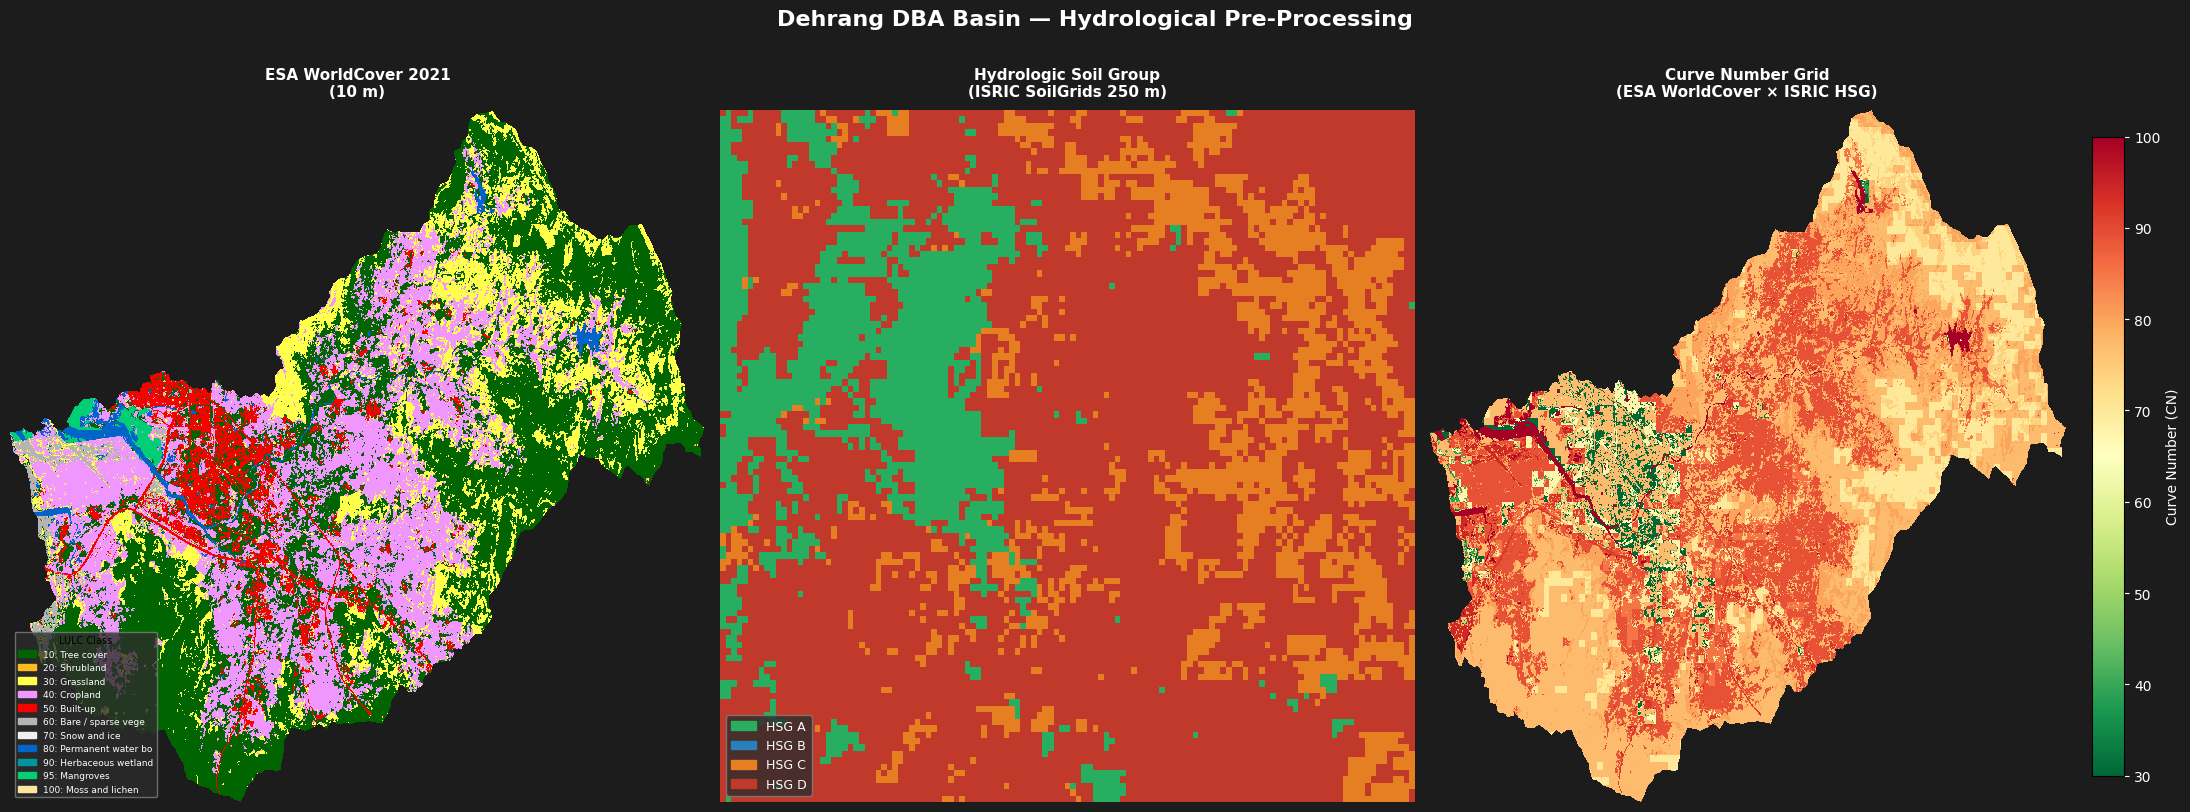

💾 Figure saved → /content/drive/MyDrive/Dehrang_DBA_Basin outputs/Hydrological_Overview.png


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor='#1c1c1c')
fig.suptitle('Dehrang DBA Basin — Hydrological Pre-Processing',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# ── Helper: display a raster array ────────────────────────────────────────
def show_raster(ax, arr, cmap, title, vmin=None, vmax=None,
                nodata=-9999, label='', legend=None):
    display = np.where(arr == nodata, np.nan, arr) if nodata else arr.astype(float)
    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto',
                   interpolation='nearest')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.axis('off')
    if legend:
        ax.legend(handles=legend, loc='lower left', fontsize=7,
                  facecolor='#2c2c2c', labelcolor='white',
                  edgecolor='gray', title_fontsize=8)
    else:
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)
        cb.ax.yaxis.label.set_color('white')
        cb.ax.tick_params(colors='white')
    return im

# ── Panel 1: ESA WorldCover LULC ──────────────────────────────────────────
if os.path.exists(WORLDCOVER_PATH):
    with rasterio.open(WORLDCOVER_PATH) as src:
        aoi_r  = gdf_wgs84.to_crs(src.crs)
        shapes = [g.__geo_interface__ for g in aoi_r.geometry]
        wc_v, _ = raster_mask(src, shapes, crop=True, nodata=0)
        wc_v    = wc_v[0]

    rgba = np.zeros((*wc_v.shape, 4))
    for cls, info in ESA_CLASSES.items():
        m = wc_v == cls
        rgba[m] = list(mcolors.to_rgba(info['color']))
    rgba[wc_v == 0] = [0,0,0,0]
    axes[0].imshow(rgba, aspect='auto', interpolation='nearest')
    axes[0].set_title('ESA WorldCover 2021\n(10 m)', color='white',
                      fontsize=11, fontweight='bold', pad=10)
    axes[0].axis('off')
    legend = [mpatches.Patch(color=v['color'],
                             label=f"{k}: {v['name'][:18]}")
              for k, v in ESA_CLASSES.items()]
    axes[0].legend(handles=legend, loc='lower left', fontsize=6.5,
                   facecolor='#2c2c2c', labelcolor='white',
                   edgecolor='gray', title='LULC Class', title_fontsize=7)

# ── Panel 2: HSG ──────────────────────────────────────────────────────────
hsg_rgba = np.zeros((*hsg_num.shape, 4))
for val, col in HSG_COLORS.items():
    m = hsg_num == val
    hsg_rgba[m] = list(mcolors.to_rgba(col))
axes[1].imshow(hsg_rgba, aspect='auto', interpolation='nearest')
axes[1].set_title('Hydrologic Soil Group\n(ISRIC SoilGrids 250 m)',
                  color='white', fontsize=11, fontweight='bold', pad=10)
axes[1].axis('off')
hsg_leg = [mpatches.Patch(color=HSG_COLORS[i],
                           label=f"HSG {HSG_META[i]}")
           for i in [1,2,3,4]]
axes[1].legend(handles=hsg_leg, loc='lower left', fontsize=9,
               facecolor='#2c2c2c', labelcolor='white', edgecolor='gray')

# ── Panel 3: CN Grid ──────────────────────────────────────────────────────
if cn_grid is not None:
    show_raster(axes[2], cn_grid, 'RdYlGn_r',
                'Curve Number Grid\n(ESA WorldCover × ISRIC HSG)',
                vmin=30, vmax=100, label='Curve Number (CN)')
else:
    axes[2].text(0.5, 0.5, 'CN Grid\nNot yet available\n(Run Section 12)',
                 ha='center', va='center', color='white', fontsize=12,
                 transform=axes[2].transAxes)
    axes[2].set_facecolor('#2c2c2c'); axes[2].axis('off')

plt.tight_layout()
VIZ_PATH = os.path.join(OUTPUT_DIR, 'Hydrological_Overview.png')
plt.savefig(VIZ_PATH, dpi=200, bbox_inches='tight', facecolor='#1c1c1c')
plt.show()
print(f"💾 Figure saved → {VIZ_PATH}")

## 🎯 Section 17 — Reproject to UTM for Dam Break Analysis
HEC-RAS 2D requires **projected coordinates** (metres) for accurate area/velocity calcs.  
For the Dehrang basin, determine the correct UTM zone and reproject all outputs.

In [44]:
# ── Determine UTM zone from basin centroid ────────────────────────────────
centroid_lon = (bounds[0] + bounds[2]) / 2
centroid_lat = (bounds[1] + bounds[3]) / 2
utm_zone     = int((centroid_lon + 180) / 6) + 1
hemisphere   = 'N' if centroid_lat >= 0 else 'S'
epsg_utm     = 32600 + utm_zone if hemisphere == 'N' else 32700 + utm_zone

print(f"📐 Basin centroid: {centroid_lat:.4f}°N, {centroid_lon:.4f}°E")
print(f"📐 UTM Zone: {utm_zone}{hemisphere}  →  EPSG:{epsg_utm}")

def reproject_raster(src_path, dst_path, target_epsg, resampling_method=Resampling.nearest):
    """Reproject a GeoTIFF to a target CRS."""
    from rasterio.warp import calculate_default_transform
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, f'EPSG:{target_epsg}', src.width, src.height, *src.bounds)
        meta = src.meta.copy()
        meta.update({'crs': f'EPSG:{target_epsg}',
                     'transform': transform,
                     'width': width, 'height': height})
        with rasterio.open(dst_path, 'w', **meta) as dst:
            for i in range(1, src.count + 1):
                reproject(source=rasterio.band(src, i),
                          destination=rasterio.band(dst, i),
                          src_transform=src.transform,
                          src_crs=src.crs,
                          dst_transform=transform,
                          dst_crs=f'EPSG:{target_epsg}',
                          resampling=resampling_method)
    print(f"  ✅ Reprojected → {os.path.basename(dst_path)}")

UTM_DIR = os.path.join(OUTPUT_DIR, f'UTM_{utm_zone}{hemisphere}')
os.makedirs(UTM_DIR, exist_ok=True)

files_to_reproject = {
    CN_PATH:        ('CN_Grid_UTM.tif',        Resampling.bilinear),
    MANN_GRID_PATH: ('Mannings_n_Grid_UTM.tif', Resampling.nearest),
    HSG_PATH:       ('HSG_Grid_UTM.tif',        Resampling.nearest),
}
if os.path.exists(WORLDCOVER_PATH):
    files_to_reproject[WORLDCOVER_PATH] = ('ESA_WorldCover_UTM.tif', Resampling.nearest)

print("\n🔄 Reprojecting all grids to UTM ...")
for src_p, (fname, res_method) in files_to_reproject.items():
    if os.path.exists(src_p):
        reproject_raster(src_p, os.path.join(UTM_DIR, fname), epsg_utm, res_method)
    else:
        print(f"  ⚠️  Skipped {fname} (source not found)")

print(f"\n✅ All UTM rasters saved in: {UTM_DIR}")

📐 Basin centroid: 18.9976°N, 73.1658°E
📐 UTM Zone: 43N  →  EPSG:32643

🔄 Reprojecting all grids to UTM ...
  ✅ Reprojected → CN_Grid_UTM.tif
  ✅ Reprojected → Mannings_n_Grid_UTM.tif
  ✅ Reprojected → HSG_Grid_UTM.tif
  ✅ Reprojected → ESA_WorldCover_UTM.tif

✅ All UTM rasters saved in: /content/drive/MyDrive/Dehrang_DBA_Basin outputs/UTM_43N


## ✅ Section 18 — Final Output Summary & Report

In [45]:
print("=" * 70)
print(" DEHRANG DBA BASIN — HYDROLOGICAL PRE-PROCESSING COMPLETE")
print("=" * 70)
print()
print("OUTPUT FILES:")
print("-" * 70)
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    subdir = os.path.basename(root)
    if level > 0:
        print(f"{indent}📁 {subdir}/")
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        sz    = os.path.getsize(fpath) / 1024
        unit  = 'KB' if sz < 1024 else 'MB'
        sz    = sz if sz < 1024 else sz/1024
        sub   = '  ' * (level + 1)
        print(f"{sub}📄 {fname:<45} {sz:>7.1f} {unit}")

print()
print("REFERENCES:")
print("-" * 70)
refs = [
    "[1] Mishra, S.K. & Singh, V.P. (2003). SCS-CN Methodology. Springer.",
    "[2] Arora, A. et al. (2021). ESA-WorldCover LULC for Indian hydrology.",
    "[3] CWPRS Technical Report (2018). Manning's n for Indian river systems.",
    "[4] Patel, D.P. et al. (2012). Extreme flood assessment, Gujarat.",
    "[5] Chow, V.T. (1959). Open-Channel Hydraulics. McGraw-Hill.",
    "[6] USDA (1986). TR-55 Urban Hydrology for Small Watersheds.",
    "[7] Kumar, R. et al. (2021). SCS-CN with ESA WorldCover, India.",
    "[8] Chandniha & Kansal (2017). SCS-CN, Jharkhand watershed.",
    "[9] Rawat & Singh (2017). LULC-based runoff, Himalayan watershed.",
    "[10] Bajracharya et al. (2018). HEC-RAS modelling, South Asia.",
    "[11] HEC-RAS Reference Manual v6.3 (USACE 2021).",
]
for r in refs:
    print(f"  {r}")

print()
print("NEXT STEPS FOR DAM BREAK ANALYSIS:")
print("-" * 70)
steps = [
    "1. Import CN_Grid_UTM.tif into HEC-HMS as SCS curve number layer",
    "2. Import Mannings_n_Grid_UTM.tif into HEC-RAS 2D terrain preprocessing",
    "3. Import ESA_WorldCover_UTM.tif as land cover layer in HEC-RAS",
    "4. Use CN Summary (AMC-II) to compute design storm runoff hydrograph",
    "5. Set up HEC-RAS 2D unsteady flow with dam breach hydrograph",
    "6. Validate Manning's n with observed gauge data if available",
]
for s in steps:
    print(f"  {s}")
print("=" * 70)

 DEHRANG DBA BASIN — HYDROLOGICAL PRE-PROCESSING COMPLETE

OUTPUT FILES:
----------------------------------------------------------------------
  📄 CN_Grid.tif                                       1.9 MB
  📄 CN_Summary.csv                                    0.1 KB
  📄 CN_Table_ESA_WorldCover.csv                       0.8 KB
  📄 ESA_WorldCover_2021.tif                         309.5 KB
  📄 HSG_grid.tif                                      2.2 KB
  📄 Hydrological_Overview.png                       731.7 KB
  📄 LULC_Area_Statistics.csv                          0.4 KB
  📄 Mannings_n_ESA_WorldCover.csv                     1.2 KB
  📄 Mannings_n_Grid.tif                               1.7 MB
  📁 soilgrids/
    📄 clay_0-5cm_mean.tif                              13.2 KB
    📄 clay_15-30cm_mean.tif                            13.4 KB
    📄 clay_5-15cm_mean.tif                             13.3 KB
    📄 sand_0-5cm_mean.tif                              13.3 KB
    📄 sand_15-30cm_mean.tif             

## 📊 Section 19 — Visualisation of all generated Maps and CSV files

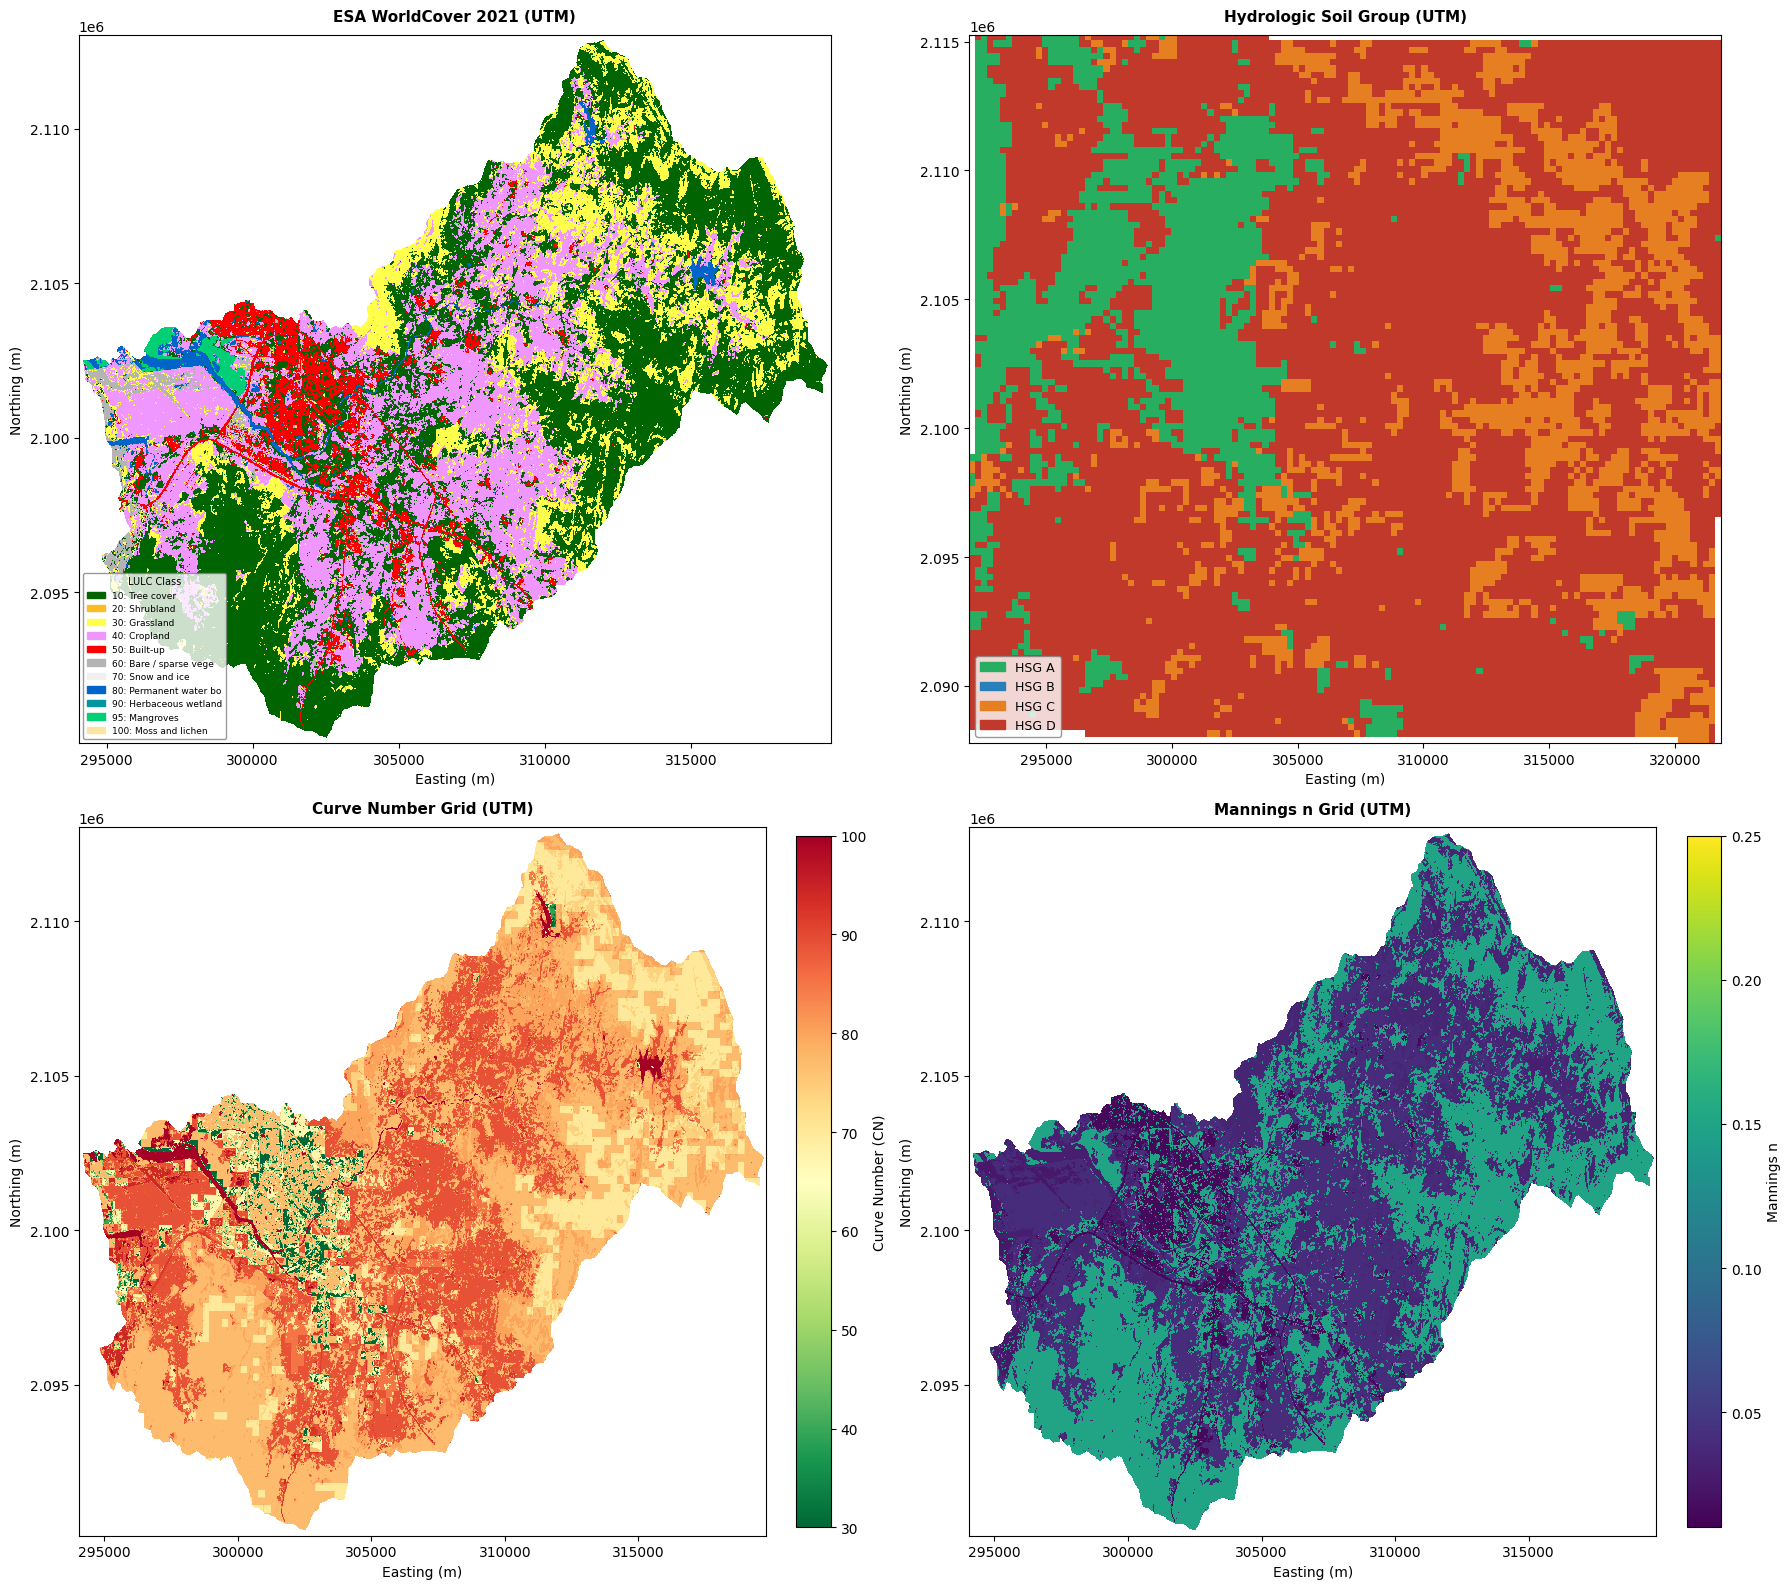

In [46]:
# Helper: display a raster array (re-defined here for modularity if run standalone)
def show_raster_utm(ax, arr, cmap, title, vmin=None, vmax=None,
                nodata=-9999, label='', legend=None, raster_meta=None):
    display_arr = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr.astype(float)
    # If raster_meta is provided, use its extent for more accurate plotting
    extent = None
    if raster_meta:
        left, bottom, right, top = rasterio.transform.array_bounds(raster_meta['height'], raster_meta['width'], raster_meta['transform'])
        extent = [left, right, bottom, top]

    im = ax.imshow(display_arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto',
                   interpolation='nearest', extent=extent)
    ax.set_title(title, color='black', fontsize=11, fontweight='bold', pad=10)
    ax.axis('on') # Turn on axis for UTM coordinates
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')

    if legend:
        ax.legend(handles=legend, loc='lower left', fontsize=7,
                  facecolor='white', labelcolor='black',
                  edgecolor='gray', title_fontsize=8)
    else:
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)
        cb.ax.yaxis.label.set_color('black')
        cb.ax.tick_params(colors='black')
    return im

fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
axes = axes.flatten() # Flatten for easy iteration

# --- Load UTM reprojected rasters and display ---

# LULC Map
LULC_UTM_PATH = os.path.join(UTM_DIR, 'ESA_WorldCover_UTM.tif')
if os.path.exists(LULC_UTM_PATH):
    with rasterio.open(LULC_UTM_PATH) as src:
        lulc_utm_arr = src.read(1)
        lulc_utm_meta = src.meta
    # Create rgba for LULC (reusing logic from Section 16)
    rgba_lulc = np.zeros((*lulc_utm_arr.shape, 4))
    for cls, info in ESA_CLASSES.items():
        m = lulc_utm_arr == cls
        rgba_lulc[m] = list(mcolors.to_rgba(info['color']))
    rgba_lulc[lulc_utm_arr == 0] = [0,0,0,0]
    axes[0].imshow(rgba_lulc, aspect='auto', interpolation='nearest',
                   extent=[lulc_utm_meta['transform'][2], lulc_utm_meta['transform'][2] + lulc_utm_meta['width'] * lulc_utm_meta['transform'][0],
                           lulc_utm_meta['transform'][5] + lulc_utm_meta['height'] * lulc_utm_meta['transform'][4], lulc_utm_meta['transform'][5]])
    axes[0].set_title('ESA WorldCover 2021 (UTM)', color='black', fontsize=11, fontweight='bold', pad=10)
    axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')
    legend_lulc = [mpatches.Patch(color=v['color'], label=f"{k}: {v['name'][:18]}")
                   for k, v in ESA_CLASSES.items()]
    axes[0].legend(handles=legend_lulc, loc='lower left', fontsize=6.5,
                   facecolor='white', labelcolor='black', edgecolor='gray', title='LULC Class', title_fontsize=7)
else:
    axes[0].text(0.5, 0.5, 'LULC UTM Grid\nNot available', ha='center', va='center', color='black', fontsize=12, transform=axes[0].transAxes)

# HSG Map
HSG_UTM_PATH = os.path.join(UTM_DIR, 'HSG_Grid_UTM.tif')
if os.path.exists(HSG_UTM_PATH):
    with rasterio.open(HSG_UTM_PATH) as src:
        hsg_utm_arr = src.read(1)
        hsg_utm_meta = src.meta
    hsg_rgba = np.zeros((*hsg_utm_arr.shape, 4))
    for val, col in HSG_COLORS.items():
        m = hsg_utm_arr == val
        hsg_rgba[m] = list(mcolors.to_rgba(col))
    axes[1].imshow(hsg_rgba, aspect='auto', interpolation='nearest',
                   extent=[hsg_utm_meta['transform'][2], hsg_utm_meta['transform'][2] + hsg_utm_meta['width'] * hsg_utm_meta['transform'][0],
                           hsg_utm_meta['transform'][5] + hsg_utm_meta['height'] * hsg_utm_meta['transform'][4], hsg_utm_meta['transform'][5]])
    axes[1].set_title('Hydrologic Soil Group (UTM)', color='black', fontsize=11, fontweight='bold', pad=10)
    axes[1].set_xlabel('Easting (m)'); axes[1].set_ylabel('Northing (m)')
    hsg_leg = [mpatches.Patch(color=HSG_COLORS[i], label=f"HSG {HSG_META[i]}")
               for i in [1,2,3,4]]
    axes[1].legend(handles=hsg_leg, loc='lower left', fontsize=9,
                   facecolor='white', labelcolor='black', edgecolor='gray')
else:
    axes[1].text(0.5, 0.5, 'HSG UTM Grid\nNot available', ha='center', va='center', color='black', fontsize=12, transform=axes[1].transAxes)

# CN Grid Map
CN_UTM_PATH = os.path.join(UTM_DIR, 'CN_Grid_UTM.tif')
if os.path.exists(CN_UTM_PATH):
    with rasterio.open(CN_UTM_PATH) as src:
        cn_utm_arr = src.read(1)
        cn_utm_meta = src.meta
    show_raster_utm(axes[2], cn_utm_arr, 'RdYlGn_r', 'Curve Number Grid (UTM)',
                    vmin=30, vmax=100, label='Curve Number (CN)', nodata=-9999, raster_meta=cn_utm_meta)
else:
    axes[2].text(0.5, 0.5, 'CN UTM Grid\nNot available', ha='center', va='center', color='black', fontsize=12, transform=axes[2].transAxes)

# Manning's n Grid Map
MANN_N_UTM_PATH = os.path.join(UTM_DIR, 'Mannings_n_Grid_UTM.tif')
if os.path.exists(MANN_N_UTM_PATH):
    with rasterio.open(MANN_N_UTM_PATH) as src:
        mann_n_utm_arr = src.read(1)
        mann_n_utm_meta = src.meta
    show_raster_utm(axes[3], mann_n_utm_arr, 'viridis', 'Mannings n Grid (UTM)',
                    vmin=0.01, vmax=0.25, label='Mannings n', nodata=-9999, raster_meta=mann_n_utm_meta)
else:
    axes[3].text(0.5, 0.5, 'Mannings n UTM Grid\nNot available', ha='center', va='center', color='black', fontsize=12, transform=axes[3].transAxes)

plt.tight_layout()
plt.show()

### CSV File Contents

In [47]:
print('--- CN Table (ESA WorldCover) ---')
cn_table_df = pd.read_csv(CN_TABLE_PATH)
display(cn_table_df)

print('\n--- Manning\'s n Table (ESA WorldCover) ---')
mannings_table_df = pd.read_csv(MANN_PATH)
display(mannings_table_df)

print('\n--- LULC Area Statistics ---')
lulc_stats_df = pd.read_csv(LULC_STATS_PATH)
display(lulc_stats_df)

print('\n--- CN Summary ---')
cn_summary_df = pd.read_csv(SUM_PATH)
display(cn_summary_df)

--- CN Table (ESA WorldCover) ---


,ESA_Code,name,A,B,C,D,notes
0,10,Tree cover,30,55,70,77,Dense forest; Mishra & Singh (2003) Table 5.3
1,20,Shrubland,35,56,70,77,Scrub/brush; TR-55 Table 2-2c poor condition
2,30,Grassland,39,61,74,80,Natural grass; TR-55 Table 2-2a fair condition
3,40,Cropland,67,78,85,89,Row crops straight rows; TR-55; Patel et al. 2009
4,50,Built-up,77,85,90,92,Urban ≥50% imperv; TR-55; Chandniha & Kansal 2017
5,60,Bare/sparse vegetation,77,86,91,94,Degraded/rocky/fallow; TR-55 Table 2-2e
6,70,Snow and ice,100,100,100,100,Treated as impervious; no infiltration
7,80,Permanent water bodies,100,100,100,100,Open water = 100% runoff; TR-55
8,90,Herbaceous wetland,78,78,78,78,Wetland uniform CN; Rawat & Singh 2017
9,95,Mangroves,30,55,70,77,Treated as dense woodland; Bajracharya et al. ...



--- Manning's n Table (ESA WorldCover) ---


,ESA_Code,name,n,n_min,n_max,desc,ref
0,10,Tree cover,0.150,0.100,0.200,Dense forest / woodland with undergrowth,Chow(1959); Arora et al.(2021); CWPRS(2018)
1,20,Shrubland,0.080,0.050,0.120,"Shrubs, scrubland, moderate stem resistance",Chow(1959); Patel et al.(2012)
2,30,Grassland,0.035,0.025,0.060,Natural short-to-medium grass; meadow,Chow(1959); CWPRS(2018)
3,40,Cropland,0.040,0.025,0.055,Agricultural fields; varies with crop season (...,Patel et al.(2012); Bajracharya et al.(2018)
4,50,Built-up,0.015,0.011,0.025,"Urban/paved; concrete, roads, impervious surfaces",Chow(1959); HEC-RAS v6(2021)
5,60,Bare/sparse vegetation,0.025,0.015,0.040,"Rocky, gravelly, sparsely vegetated degraded land",Chow(1959); Arora et al.(2021)
6,70,Snow and ice,0.010,0.008,0.020,"Smooth glacial ice, low friction surface",Chow(1959)
7,80,Permanent water bodies,0.030,0.020,0.060,"Lakes, reservoirs, rivers; HEC-RAS channel value",HEC-RAS v6(2021); CWPRS(2018)
8,90,Herbaceous wetland,0.070,0.050,0.100,"Reeds, sedges, emergent wetland vegetation",Chow(1959); Patel et al.(2012)
9,95,Mangroves,0.150,0.100,0.250,Dense mangrove forest; very high hydraulic res...,Arora et al.(2021); Bajracharya et al.(2018)



--- LULC Area Statistics ---


,ESA_Code,LULC_Name,Pixels,Area_km2,Area_pct,CN_HSG_B,Mannings_n
0,10,Tree cover,1290302,121.186,42.82,55,0.150
1,40,Cropland,861333,80.897,28.58,78,0.040
2,30,Grassland,534424,50.193,17.73,61,0.035
3,50,Built-up,204262,19.184,6.78,85,0.015
4,80,Permanent water bodies,51316,4.820,1.70,100,0.030
5,60,Bare / sparse vegetation,49062,4.608,1.63,86,0.025
6,95,Mangroves,22712,2.133,0.75,55,0.150
7,20,Shrubland,43,0.004,0.00,56,0.080
8,90,Herbaceous wetland,15,0.001,0.00,78,0.070



--- CN Summary ---


,Parameter,Value
0,AMC-I CN,45.91
1,AMC-II CN,65.94
2,AMC-III CN,81.93
3,S_mm,131.18
4,Ia_lambda_0.2_mm,26.24
5,Ia_lambda_0.1_mm,13.12


## 🗺️ Section 20 — Interactive Watershed Map with Basemap
This map displays the Dehrang DBA Basin boundary on a satellite basemap, with no fill inside the basin for clarity.

In [48]:
# Create an interactive map centered on the basin
m = geemap.Map(center=[centroid_lat, centroid_lon], zoom=10)

# Add a basemap. 'HYBRID' provides satellite imagery with labels.
m.add_basemap('HYBRID')

# Define a style for the basin boundary:
# - color: a distinct color for the boundary line (e.g., blue)
# - fillColor: '00000000' makes the interior completely transparent
# - width: thickness of the boundary line

basin_style = {
    'color': '#4285F4',  # Google Blue
    'fillColor': '00000000', # Fully transparent
    'width': 2
}

# Add the GEE AOI geometry to the map with the defined style
m.addLayer(aoi_ee, basin_style, 'Dehrang DBA Basin Boundary')

# Display the map
m

Map(center=[np.float64(18.997579573248778), np.float64(73.16584728191532)], controls=(WidgetControl(options=['…

In [53]:
# Install contextily for basemaps
!pip install contextily --quiet
print("✅ contextily installed!")

✅ contextily installed!


In [54]:
import contextily as cx

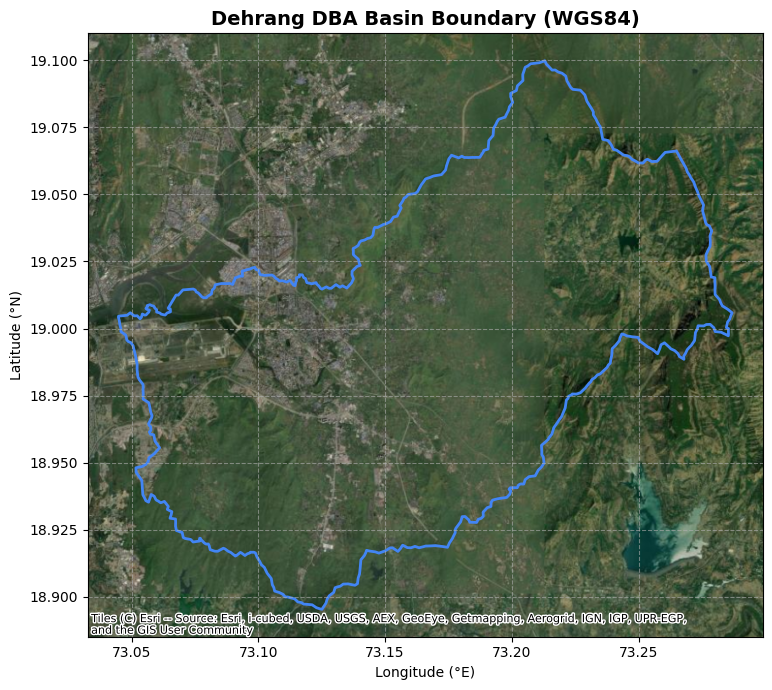

In [56]:
fig, ax = plt.subplots(figsize=(8, 7))
gdf_wgs84.plot(ax=ax, color='none', edgecolor='#4285F4', linewidth=2) # Changed fill color to 'none'
ax.set_title('Dehrang DBA Basin Boundary (WGS84)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.grid(True, linestyle='--', alpha=0.6)
cx.add_basemap(ax, crs=gdf_wgs84.crs.to_string(), source=cx.providers.Esri.WorldImagery) # Add satellite basemap
plt.tight_layout()
plt.show()